Dataset berhasil dimuat: 200 berita.
Distribusi Kelas:
label
sport      100
finance    100
Name: count, dtype: int64

Model Skip-gram selesai dilatih dengan 5328 kosakata unik.

Matriks Vektor Dokumen terbentuk dengan ukuran: (200, 100)

Data berhasil dibagi: 160 Data Latih dan 40 Data Uji.

Ukuran Data Latih Setelah PCA : (160, 3)
Ukuran Data Uji Setelah PCA   : (40, 3)
Persentase Informasi Terjaga  : 91.82%

--- HASIL EVALUASI MODEL ---
Akurasi Data Uji: 85.00%

              precision    recall  f1-score   support

     Finance       0.89      0.80      0.84        20
       Sport       0.82      0.90      0.86        20

    accuracy                           0.85        40
   macro avg       0.85      0.85      0.85        40
weighted avg       0.85      0.85      0.85        40



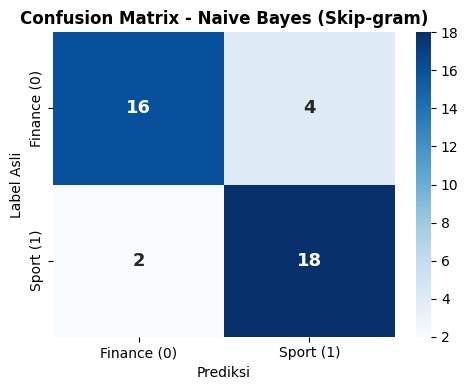


Artefak model berhasil disimpan (w2v_model.model, pca_model.pkl, gnb_model.pkl).

--- PENGUJAN TEKS BARU ---
Teks Berita  : 'IHSG bergerak menguat seiring peningkatan volume transaksi saham di pasar modal'
Hasil Prediksi : Finance
Probabilitas   : Finance = 76.35%, Sport = 23.65%


In [3]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

# ==============================================================================
# TAHAP 1: MEMUAT DATASET & TOKENISASI
# ==============================================================================
# Memuat dataset hasil preprocessing
df = pd.read_csv("detik_preprocessed.csv")
df["isi_berita_clean"] = df["isi_berita_clean"].fillna("")

# Tokenisasi teks menjadi list kata dan mapping label numerik
df["tokens"] = df["isi_berita_clean"].apply(lambda x: x.split())
df["label_encoded"] = df["label"].map({"finance": 0, "sport": 1})

sentences = df["tokens"].tolist()
labels = df["label_encoded"].values

print(f"Dataset berhasil dimuat: {len(df)} berita.")
print(f"Distribusi Kelas:\n{df['label'].value_counts()}\n")

# ==============================================================================
# TAHAP 2: PELATIHAN MODEL WORD2VEC (SKIP-GRAM)
# ==============================================================================
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,  # 100 dimensi per kata
    window=2,  # Jendela konteks (2 kata kiri & kanan)
    sg=1,  # Arsitektur Skip-gram
    min_count=1,  # Memproses seluruh kata
    workers=4,
    seed=42,
)

print(
    f"Model Skip-gram selesai dilatih dengan {len(w2v_model.wv)} kosakata unik.\n"
)


# ==============================================================================
# TAHAP 3: EKSTRAKSI VEKTOR DOKUMEN (AVERAGE WORD VECTOR)
# ==============================================================================
def get_document_vector(tokens, model):
    valid_vectors = [
        model.wv[word] for word in tokens if word in model.wv
    ]
    if len(valid_vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(valid_vectors, axis=0)


# Membentuk matriks vektor dokumen (N x 100)
X_vec = np.array([get_document_vector(doc, w2v_model) for doc in sentences])
print(f"Matriks Vektor Dokumen terbentuk dengan ukuran: {X_vec.shape}\n")

# ==============================================================================
# TAHAP 4: PEMBAGIAN DATA (TRAIN-TEST SPLIT 80:20)
# ==============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_vec, labels, test_size=0.20, random_state=42, stratify=labels
)

print(
    f"Data berhasil dibagi: {X_train.shape[0]} Data Latih dan {X_test.shape[0]} Data Uji.\n"
)

# ==============================================================================
# TAHAP 5: REDUKSI DIMENSI DENGAN PCA
# ==============================================================================
# Mempertahankan minimal 85% varians informasi
pca = PCA(n_components=0.85, random_state=42)

# Fit & transform hanya pada data latih, lalu transform pada data uji
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

cum_variance = np.sum(pca.explained_variance_ratio_) * 100
print(f"Ukuran Data Latih Setelah PCA : {X_train_pca.shape}")
print(f"Ukuran Data Uji Setelah PCA   : {X_test_pca.shape}")
print(f"Persentase Informasi Terjaga  : {cum_variance:.2f}%\n")

# ==============================================================================
# TAHAP 6: PELATIHAN & EVALUASI GAUSSIAN NAIVE BAYES
# ==============================================================================
nb_model = GaussianNB()
nb_model.fit(X_train_pca, y_train)

# Prediksi data uji
y_pred = nb_model.predict(X_test_pca)

# Evaluasi Metrik
acc = accuracy_score(y_test, y_pred)
print(f"--- HASIL EVALUASI MODEL ---")
print(f"Akurasi Data Uji: {acc * 100:.2f}%\n")
print(classification_report(y_test, y_pred, target_names=["Finance", "Sport"]))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Finance (0)", "Sport (1)"],
    yticklabels=["Finance (0)", "Sport (1)"],
    annot_kws={"size": 13, "weight": "bold"},
)
plt.title("Confusion Matrix - Naive Bayes (Skip-gram)", fontweight="bold")
plt.xlabel("Prediksi")
plt.ylabel("Label Asli")
plt.tight_layout()
plt.show()

# ==============================================================================
# TAHAP 7: MENYIMPAN ARTEFAK MODEL FOR DEPLOYMENT / INFERENSI
# ==============================================================================
w2v_model.save("w2v_model.model")
joblib.dump(pca, "pca_model.pkl")
joblib.dump(nb_model, "gnb_model.pkl")
print("\nArtefak model berhasil disimpan (w2v_model.model, pca_model.pkl, gnb_model.pkl).\n")


# ==============================================================================
# TAHAP 8: FUNGSI PREDIKSI UNTUK TEKS BARU (UNSEEN DATA)
# ==============================================================================
def prediksi_berita_baru(teks, model_w2v, model_pca, model_gnb):
    tokens = teks.lower().split()
    doc_vec = get_document_vector(tokens, model_w2v)
    doc_pca = model_pca.transform([doc_vec])

    pred = model_gnb.predict(doc_pca)[0]
    prob = model_gnb.predict_proba(doc_pca)[0]

    label_map = {0: "Finance", 1: "Sport"}
    return label_map[pred], prob


# Pengujian pada sampel teks baru
berita_uji = "IHSG bergerak menguat seiring peningkatan volume transaksi saham di pasar modal"
kategori, probabilitas = prediksi_berita_baru(
    berita_uji, w2v_model, pca, nb_model
)

print("--- PENGUJAN TEKS BARU ---")
print(f"Teks Berita  : '{berita_uji}'")
print(f"Hasil Prediksi : {kategori}")
print(
    f"Probabilitas   : Finance = {probabilitas[0]*100:.2f}%, Sport = {probabilitas[1]*100:.2f}%"
)

=== TAHAP 1: DATASET & TOKENISASI ===
• Total Data Berita : 200
• Distribusi Label  :
label
sport      100
finance    100

=== TAHAP 2: PELATIHAN WORD2VEC (SKIP-GRAM) ===
• Ukuran Kosakata (Vocabulary) : 5328 kata
• Dimensi Vektor per Kata      : 100 dimensi

=== TAHAP 3: VEKTOR DOKUMEN (AVERAGE WORD VECTOR) ===
• Ukuran Matriks Dokumen (X_vec) : (200, 100)

=== TAHAP 4: TRAIN-TEST SPLIT (80:20) ===
• Ukuran Data Latih (X_train) : (160, 100)
• Ukuran Data Uji   (X_test)  : (40, 100)

=== TAHAP 5: REDUKSI DIMENSI (PCA) ===
• Jumlah Komponen Utama (PC) : 3 Komponen
• Persentase Varians Terjaga : 91.48%
• Shape X_train_pca          : (160, 3)
• Shape X_test_pca           : (40, 3)

=== TAHAP 6: EVALUASI GAUSSIAN NAIVE BAYES ===
• Akurasi Data Uji : 87.50%

--- Classification Report ---
              precision    recall  f1-score   support

     Finance       0.89      0.85      0.87        20
       Sport       0.86      0.90      0.88        20

    accuracy                           0.8

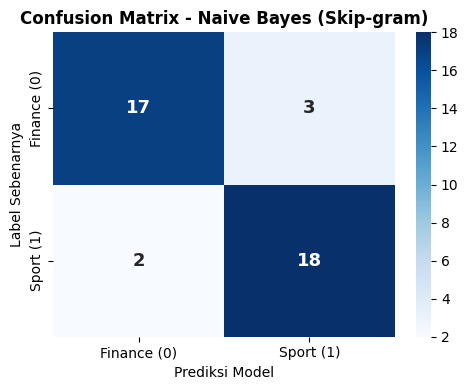


[INFO] Seluruh model berhasil disimpan (w2v_model.model, pca_model.pkl, gnb_model.pkl).

=== TAHAP 7: PENGUJIAN DATA BARU ===
• Teks Input     : 'IHSG ditutup menguat seiring peningkatkan volume transaksi saham perbankan'
• Hasil Prediksi : Sport
• Probabilitas   : Finance = 43.81%, Sport = 56.19%


In [4]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

# ==============================================================================
# TAHAP 1: MEMUAT DATASET & TOKENISASI
# ==============================================================================
# 1. Memuat dataset hasil preprocessing
df = pd.read_csv("detik_preprocessed.csv")
df["isi_berita_clean"] = df["isi_berita_clean"].fillna("")

# 2. Pembentukan token kata dan pemetaan label numerik (Finance=0, Sport=1)
df["tokens"] = df["isi_berita_clean"].apply(lambda x: x.split())
df["label_encoded"] = df["label"].map({"finance": 0, "sport": 1})

sentences = df["tokens"].tolist()
labels = df["label_encoded"].values

print("=== TAHAP 1: DATASET & TOKENISASI ===")
print(f"• Total Data Berita : {len(df)}")
print(f"• Distribusi Label  :\n{df['label'].value_counts().to_string()}\n")


# ==============================================================================
# TAHAP 2: PELATIHAN MODEL WORD2VEC (SKIP-GRAM)
# ==============================================================================
# Inisialisasi model Word2Vec Skip-gram (sg=1) dengan window=2
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,  # 100 dimensi fitur per kata
    window=2,  # Memperhatikan 2 kata di kiri & 2 kata di kanan target
    sg=1,  # 1 = Arsitektur Skip-gram
    min_count=1,  # Mengakomodasi seluruh kata unik
    workers=4,
    seed=42,
)

print("=== TAHAP 2: PELATIHAN WORD2VEC (SKIP-GRAM) ===")
print(f"• Ukuran Kosakata (Vocabulary) : {len(w2v_model.wv)} kata")
print(f"• Dimensi Vektor per Kata      : {w2v_model.wv.vector_size} dimensi\n")


# ==============================================================================
# TAHAP 3: PEMBUATAN VEKTOR DOKUMEN (AVERAGE WORD VECTOR)
# ==============================================================================
def get_document_vector(tokens, model):
    valid_vectors = [
        model.wv[word] for word in tokens if word in model.wv
    ]
    if len(valid_vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(valid_vectors, axis=0)


# Membentuk matriks representasi dokumen berukuran (N x 100)
X_vec = np.array([get_document_vector(doc, w2v_model) for doc in sentences])

print("=== TAHAP 3: VEKTOR DOKUMEN (AVERAGE WORD VECTOR) ===")
print(f"• Ukuran Matriks Dokumen (X_vec) : {X_vec.shape}\n")


# ==============================================================================
# TAHAP 4: PEMBAGIAN DATASET (TRAIN-TEST SPLIT 80:20)
# ==============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_vec, labels, test_size=0.20, random_state=42, stratify=labels
)

print("=== TAHAP 4: TRAIN-TEST SPLIT (80:20) ===")
print(f"• Ukuran Data Latih (X_train) : {X_train.shape}")
print(f"• Ukuran Data Uji   (X_test)  : {X_test.shape}\n")


# ==============================================================================
# TAHAP 5: REDUKSI DIMENSI DENGAN PCA
# ==============================================================================
# PCA diinisialisasi untuk mempertahankan minimal 85% varians informasi
pca_doc = PCA(n_components=0.85, random_state=42)

# Menerapkan fit_transform HANYA pada X_train, lalu transform pada X_test
X_train_pca = pca_doc.fit_transform(X_train)
X_test_pca = pca_doc.transform(X_test)

cum_variance = np.sum(pca_doc.explained_variance_ratio_) * 100

print("=== TAHAP 5: REDUKSI DIMENSI (PCA) ===")
print(
    f"• Jumlah Komponen Utama (PC) : {X_train_pca.shape[1]} Komponen"
)
print(f"• Persentase Varians Terjaga : {cum_variance:.2f}%")
print(f"• Shape X_train_pca          : {X_train_pca.shape}")
print(f"• Shape X_test_pca           : {X_test_pca.shape}\n")


# ==============================================================================
# TAHAP 6: PELATIHAN & EVALUASI GAUSSIAN NAIVE BAYES
# ==============================================================================
nb_model = GaussianNB()
nb_model.fit(X_train_pca, y_train)

# Prediksi label pada data uji
y_pred = nb_model.predict(X_test_pca)

# Evaluasi Metrik
acc = accuracy_score(y_test, y_pred)

print("=== TAHAP 6: EVALUASI GAUSSIAN NAIVE BAYES ===")
print(f"• Akurasi Data Uji : {acc * 100:.2f}%\n")
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=["Finance", "Sport"]))

# Plotting Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Finance (0)", "Sport (1)"],
    yticklabels=["Finance (0)", "Sport (1)"],
    annot_kws={"size": 13, "weight": "bold"},
)
plt.title("Confusion Matrix - Naive Bayes (Skip-gram)", fontweight="bold")
plt.xlabel("Prediksi Model")
plt.ylabel("Label Sebenarnya")
plt.tight_layout()
plt.show()


# ==============================================================================
# TAHAP 7: MENYIMPAN MODEL & PENGUJIAN DATA BARU (UNSEEN DATA)
# ==============================================================================
# 1. Simpan artefak model untuk deployment (misal: Streamlit)
w2v_model.save("w2v_model.model")
joblib.dump(pca_doc, "pca_model.pkl")
joblib.dump(nb_model, "gnb_model.pkl")
print(
    "\n[INFO] Seluruh model berhasil disimpan (w2v_model.model, pca_model.pkl, gnb_model.pkl)."
)


# 2. Fungsi inferensi data baru
def prediksi_teks_baru(teks, model_w2v, model_pca, model_gnb):
    tokens = teks.lower().split()
    doc_vec = get_document_vector(tokens, model_w2v)
    doc_pca = model_pca.transform([doc_vec])

    pred = model_gnb.predict(doc_pca)[0]
    prob = model_gnb.predict_proba(doc_pca)[0]

    label_map = {0: "Finance", 1: "Sport"}
    return label_map[pred], prob


# Contoh Pengujian Teks Uji Baru
teks_sampel = "IHSG ditutup menguat seiring peningkatkan volume transaksi saham perbankan"
kategori, probabilitas = prediksi_teks_baru(
    teks_sampel, w2v_model, pca_doc, nb_model
)

print("\n=== TAHAP 7: PENGUJIAN DATA BARU ===")
print(f"• Teks Input     : '{teks_sampel}'")
print(f"• Hasil Prediksi : {kategori}")
print(
    f"• Probabilitas   : Finance = {probabilitas[0]*100:.2f}%, Sport = {probabilitas[1]*100:.2f}%"
)